In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table  
from astropy.coordinates import SkyCoord      
from astropy import units as u                 
from astropy.cosmology import Planck18 as cosmo  
from matplotlib.colors import LogNorm


In [2]:
path_to_catalog = '/users/PCON0003/kyledrees985/fullcatalogdesi/zall-pix-iron.fits'
catalog = Table.read(path_to_catalog)

In [3]:
# trim catalog
RA_max = 360   # RA ranges from 0-360
DEC_max = 90   # DEC ranges from -90 to 90 (although DESI is in the north, so you won't see many below 0)
catalog = catalog[(catalog['TARGET_RA'] < RA_max) & (catalog['TARGET_DEC'] < DEC_max)]

# limit redshift
z_min = 0.01 # below this, they're mostly stars or errors.
z_max = 1.5    # DESI goes higher than this, but it is sparse and harder to visualize. You can increase this if you want to see more the high-z objects.
catalog = catalog[(catalog['Z'] > z_min) & (catalog['Z'] < z_max)]

# remove objects with bad redshift measurements
catalog = catalog[catalog['ZWARN'] == 0]  # ZWARN=0 means good redshift fit
catalog = catalog[catalog['DELTACHI2'] > 25]  # confident redshift: large gap between best and second-best fit
catalog = catalog[catalog['ZCAT_PRIMARY'] == True]  # avoid counting the same galaxy twice
catalog = catalog[catalog['COADD_FIBERSTATUS'] == 0]  # fiber worked correctly


# remove galaxies with unrealistic imaging fluxes
flux_g_max = 50  # these are quite faint. You also can't have negative flux!
flux_g_min = 0
flux_r_max = 50  
flux_r_min = 0
flux_z_max = 50  
flux_z_min = 0
catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min)]

In [6]:
dev_mask = catalog['MORPHTYPE'] == b'DEV'   # de Vaucouleurs
exp_mask = catalog['MORPHTYPE'] == b'EXP'   # Exponential disk
rex_mask = catalog['MORPHTYPE'] == b'REX'   # Round exponential 
ser_mask = catalog['MORPHTYPE'] == b'SER'   # Free Sérsic
psf_mask = catalog['MORPHTYPE'] == b'PSF'   # Compact/unresolved

#from what ive seen 2.5 is a decent cut off for deciding if the galxy if an early or late type.
N_THRESH = 2.5
sersic_n = catalog['SERSIC']

ser_early = ser_mask & (sersic_n >= N_THRESH)
ser_late  = ser_mask & (sersic_n <  N_THRESH)

In [7]:
# convert RA, DEC, Z to 3D coordinates
comoving_distance = cosmo.comoving_distance(catalog['Z'])

# TARGET_RA/TARGET_DEC already carry a 'deg' unit from the FITS header,
# so multiplying by u.degree again would square it (deg -> deg^2).
# np.asarray() strips that attached unit so u.degree can be applied cleanly.
ra = np.asarray(catalog['TARGET_RA'], dtype=float) * u.degree
dec = np.asarray(catalog['TARGET_DEC'], dtype=float) * u.degree

coords = SkyCoord(ra=ra, dec=dec, distance=comoving_distance)
x = coords.cartesian.x
y = coords.cartesian.y
z = coords.cartesian.z

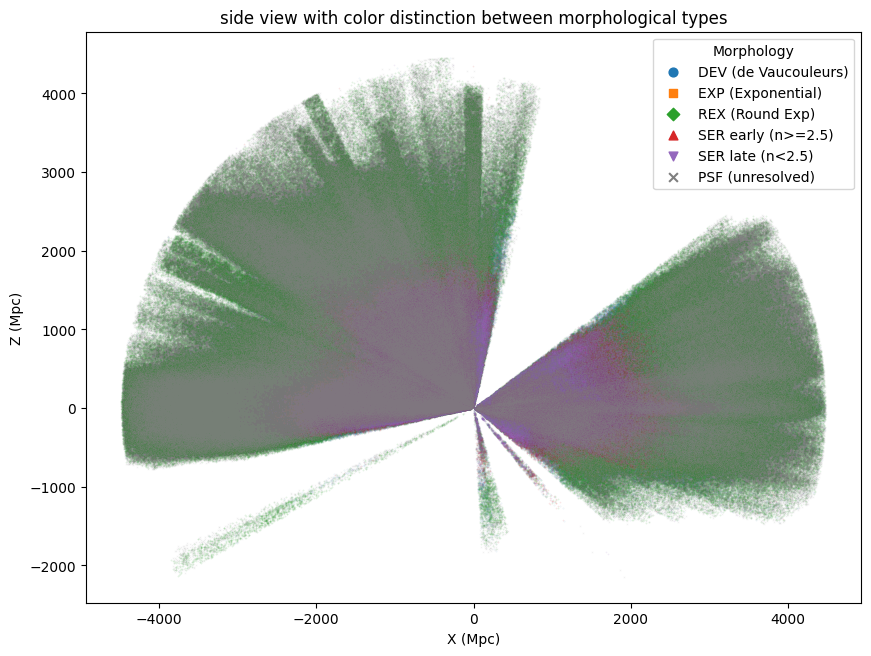

In [8]:
# define the morph types you want to plot, with a color/marker for each
morph_types = {
    'DEV (de Vaucouleurs)': (dev_mask, '#1f77b4', 'o'),
    'EXP (Exponential)':    (exp_mask, '#ff7f0e', 's'),
    'REX (Round Exp)':      (rex_mask, '#2ca02c', 'D'),
    'SER early (n>=2.5)':   (ser_early, '#d62728', '^'),
    'SER late (n<2.5)':     (ser_late, '#9467bd', 'v'),
    'PSF (unresolved)':     (psf_mask, '#7f7f7f', 'x'),
}

fig = plt.figure(figsize=(10, 10))

for label, (mask, color, marker) in morph_types.items():
    plt.scatter(x[mask].value, z[mask].value,
                s=0.1,
                c=color,
                marker=marker,
                alpha=0.1,
                label=label)

plt.xlabel('X (Mpc)')
plt.ylabel('Z (Mpc)')
plt.title('side view with color distinction between morphological types')
lgnd = plt.legend(loc="upper right", title="Morphology")
for handle in lgnd.legend_handles:
    handle.set_sizes([40.0])
    handle.set_alpha(1.0)
plt.gca().set_aspect('equal')
plt.show()

In [10]:
from scipy.stats import binned_statistic
from astropy.visualization import make_lupton_rgb

# ── 0. Apparent magnitudes ──
app_mag_G = -2.5*np.log10(catalog['FLUX_G'])+22.5 
app_mag_R = -2.5*np.log10(catalog['FLUX_R'])+22.5 
app_mag_Z = -2.5*np.log10(catalog['FLUX_Z'])+22.5 
app_mag_W1 = -2.5 * np.log10(np.clip(catalog['FLUX_W1'], 0.001, None)) + 22.5
app_mag_W2 = -2.5 * np.log10(np.clip(catalog['FLUX_W2'], 0.001, None)) + 22.5

# ── 0b. Absolute magnitudes ──
redshift = catalog['Z']

def apparent_to_absolute_magnitude(m, z):
    d_L = cosmo.luminosity_distance(z)  
    M = m - 5 * np.log10(d_L.to(u.pc).value) + 5  
    return M

abs_mag_g = apparent_to_absolute_magnitude(app_mag_G, redshift)
abs_mag_r = apparent_to_absolute_magnitude(app_mag_R, redshift)
abs_mag_z = apparent_to_absolute_magnitude(app_mag_Z, redshift)
abs_mag_w1 = apparent_to_absolute_magnitude(app_mag_W1, redshift)
abs_mag_w2 = apparent_to_absolute_magnitude(app_mag_W2, redshift)

# ── 0c. Reddening trend line (needed for corrected_color / slope) ──
color_g_r = abs_mag_g - abs_mag_r
z_vals = catalog['Z']
color_vals = color_g_r

math_mask = (z_vals > 0.02) & (z_vals < 0.15) & (color_vals > 0.0) & (color_vals < 2.5)
z_math = z_vals[math_mask]
color_math = color_vals[math_mask]

bins = np.linspace(0.02, 0.15, 10)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

medians, _, _ = binned_statistic(z_math, color_math, statistic='median', bins=bins)
valid = ~np.isnan(medians)

slope, intercept = np.polyfit(bin_centers[valid], medians[valid], 1)

# ── 1. corrected_color ──
catalog['corrected_color'] = color_g_r - (slope * catalog['Z'])

# ── 2. color_r, color_g, color_b (Lupton RGB) ──
lum_r = 10 ** (-0.4 * abs_mag_r)
lum_g = 10 ** (-0.4 * abs_mag_g)

norm = np.percentile(lum_r, 5)
lum_r = lum_r / norm
lum_g = lum_g / norm

rest_R = lum_r
rest_G = (lum_r + lum_g) / 2.0
rest_B = lum_g * 1.5

rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)
r_arr, g_arr, b_arr = rest_rgb_array.T

catalog['color_r'] = r_arr / 255.0
catalog['color_g'] = g_arr / 255.0
catalog['color_b'] = b_arr / 255.0

# ── 3. object_subtype (needs corrected_color) ──
conditions = [
    (catalog['SPECTYPE'] == 'QSO'),
    (catalog['corrected_color'] < 0.5),
    (catalog['corrected_color'] >= 0.5)
]
choices = [3, 1, 2]
catalog['object_subtype'] = np.select(conditions, choices, default=1)

# ── 4. size_scale (needs object_subtype) ──
raw_luminosity = 10 ** (-0.4 * abs_mag_r)
object_subtypes = catalog['object_subtype']
normalized_size = np.zeros(len(catalog))

galaxy_mask = (object_subtypes == 1) | (object_subtypes == 2)
gal_lum = raw_luminosity[galaxy_mask]
min_gal = np.percentile(gal_lum, 1)
max_gal = np.percentile(gal_lum, 99)
clipped_gal = np.clip(gal_lum, min_gal, max_gal)
normalized_size[galaxy_mask] = 1.0 + 7.0 * (clipped_gal - min_gal) / (max_gal - min_gal)

qso_mask = (object_subtypes == 3)
qso_lum = raw_luminosity[qso_mask]
min_qso = np.percentile(qso_lum, 1)
max_qso = np.percentile(qso_lum, 99)
clipped_qso = np.clip(qso_lum, min_qso, max_qso)
normalized_size[qso_mask] = 9.0 + 5.0 * (clipped_qso - min_qso) / (max_qso - min_qso)

catalog['size_scale'] = normalized_size

# ── 5. final_brightness ──
min_mag = app_mag_R.min()
max_mag = app_mag_R.max()
normalized_mag = (app_mag_R - min_mag) / (max_mag - min_mag)
catalog['final_brightness'] = 1.0 - normalized_mag
catalog['final_brightness'] = np.clip(catalog['final_brightness'], 0.1, 1.0)

# ── Sanity check ──
print(catalog.colnames)

['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'SPGRPVAL', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 'RELEASE', 'BRICKNAME', 'BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'FIBERTOTFLUX_G', 'FIBERTOTFLUX_R', 'FIBERTOTFLUX_Z', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'REF_ID', 'REF_CAT', 'GAIA_PHOT_G_MEAN_MAG', 'GAIA_PHOT_BP_MEAN_MAG', 'GAIA_PHOT_RP_MEAN_MAG', 'PARALLAX', 'PHOTSYS', 'PRIORITY_INIT', 'NUMOBS_INIT', 'CMX_TARGET', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'SV1_DESI_TARGET', 'SV1_BGS_TARGET', 'SV1_MWS_TARGET', 'SV1_SCND_TARGET', 'SV2_DESI_TARGET', 'SV2_BGS_TARGET', 'SV2_MWS_TARGE

In [ ]:
# ASSIGN PLANETARIUM SUBTYPES 
conditions = [
    (catalog['SPECTYPE'] == 'QSO'),
    (catalog['MORPHTYPE'] == b'DEV'),
    (catalog['MORPHTYPE'] == b'EXP'),
    (catalog['MORPHTYPE'] == b'REX'),
    (ser_mask & (sersic_n >= N_THRESH)),
    (ser_mask & (sersic_n <  N_THRESH)),
    (catalog['MORPHTYPE'] == b'PSF')
]
choices = [1, 2, 3, 4, 5, 6, 7]

# Apply the choices globally to the catalog column
catalog['object_subtype'] = np.select(conditions, choices, default=2)

print("--- Step 1: Subtype Summary ---")
print(f"point sources mapped, foreground stars or extremely faint galaxies (ID: 7):      {np.sum(catalog['object_subtype'] == 7)}")
print(f"Sersics mapped with a n value less than 2.5, likely spiral (ID: 6):  {np.sum(catalog['object_subtype'] == 6)}")
print(f"Sersics mapped with a n value greater than 2.5, likely eliptical (ID: 5):      {np.sum(catalog['object_subtype'] == 5)}")
print(f"round exponentials mapped, far away, hard to make out (REX) (ID: 4):  {np.sum(catalog['object_subtype'] == 4)}")
print(f"Spirals mapped  (EXP) (ID: 3):      {np.sum(catalog['object_subtype'] == 3)}")
print(f"Ellipticals mapped (DEV)(ID: 2):  {np.sum(catalog['object_subtype'] == 2)}")
print(f"Quasars mapped (ID: 1):      {np.sum(catalog['object_subtype'] == 1)}")
print("--------------------------------\n")


# DUAL-NORMALIZATION SIZE SCALING FACTOR (GALAXY VS. QSO VARIABILITY)
# Convert absolute magnitude (r-band) to a linear luminosity
raw_luminosity = 10 ** (-0.4 * abs_mag_r
)
object_subtypes = catalog['object_subtype']

# Create a blank array to hold final customized visual sizes
normalized_size = np.zeros(len(catalog))

# PART A: SCALE THE STANDARD GALAXIES ---
galaxy_mask = (object_subtypes == 2) | (object_subtypes == 3) | (object_subtypes == 4) | (object_subtypes == 5) | (object_subtypes == 6) | (object_subtypes == 7)
gal_lum = raw_luminosity[galaxy_mask]

# Clip galaxy outliers at the 1st and 99th percentiles to prevent a few super-bright/dim galaxies from dominating the size scaling
min_gal = np.percentile(gal_lum, 1)
max_gal = np.percentile(gal_lum, 99)
clipped_gal = np.clip(gal_lum, min_gal, max_gal)

# Map galaxies to a smooth baseline visual size scale between 1.0 and 8.0
normalized_size[galaxy_mask] = 1.0 + 7.0 * (clipped_gal - min_gal) / (max_gal - min_gal)


# PART B: INDIVIDUAL QUASAR VARIABILITY SCALING (Subtype 1) ---
qso_mask = (object_subtypes == 1)
qso_lum = raw_luminosity[qso_mask]

# Clip quasar outliers at their own 1st and 99th percentiles
min_qso = np.percentile(qso_lum, 1)
max_qso = np.percentile(qso_lum, 99)
clipped_qso = np.clip(qso_lum, min_qso, max_qso)

# Map quasars to their own scale between 9.0 and 14.0 (Even though they are technically very small, we want them to visually pop)
# Dimmer/more distant quasars will sit near 9.0, absolute monsters will scale up to 14.0
normalized_size[qso_mask] = 9.0 + 5.0 * (clipped_qso - min_qso) / (max_qso - min_qso)


# Lock the multi-tier calculated scale directly back into the catalog
catalog['size_scale'] = normalized_size

print("--- Step 2: Advanced Size Scaling Summary ---")
print(f"  Standard Galaxy size range:  {np.min(normalized_size[galaxy_mask]):.2f} to {np.max(normalized_size[galaxy_mask]):.2f}")
print(f"  Individual Quasar size range: {np.min(normalized_size[qso_mask]):.2f} to {np.max(normalized_size[qso_mask]):.2f}")
print("------------------------------------\n")

# 1. Find the bounds of your R-band apparent magnitude
min_mag = app_mag_R.min()  # The brightest galaxy (smallest number)
max_mag = app_mag_R.max()  # The dimmest galaxy (largest number)

# 2. Normalize the magnitude into a 0.0 to 1.0 scale
normalized_mag = (app_mag_R - min_mag) / (max_mag - min_mag)

# 3. INVERT IT so the brightest galaxies (lowest mag) get the highest multiplier
catalog['final_brightness'] = 1.0 - normalized_mag

# 4. Clip the bottom end so the dimmest galaxies don't completely vanish in OpenSpace
catalog['final_brightness'] = np.clip(catalog['final_brightness'], 0.1, 1.0)


# Now build the production table

# ASSEMBLE AND EXPORT THE FINAL MASTER CSV FILE
# Append 'corrected_color', 'object_subtype', 'size_scale', and 'final_brightness' to the very end
final_production_table = Table(
    [
        x, y, z,
        catalog['color_r'], catalog['color_g'], catalog['color_b'], catalog['object_subtype'],
        catalog['size_scale'], catalog['final_brightness']
    ], 
    names=[
        'x', 'y', 'z',
        'color_r', 'color_g', 'color_b', 'object_subtype',
        'size_scale', 'final_brightness'
    ]
)

# Clean up any 2D telescope column array dimensions
for col in final_production_table.colnames:
    if len(final_production_table[col].shape) > 1:
        final_production_table[col] = np.squeeze(final_production_table[col])


import os
os.makedirs('openspace_assets', exist_ok=True)

final_production_table.write('openspace_assets/desi_morphtype_catalog.csv', format='csv', overwrite=True)


--- Step 1: Subtype Summary ---
point sources mapped, foreground stars or extremely faint galaxies (ID: 7):      1377698
Sersics mapped with a n value less than 2.5, likely spiral (ID: 6):  1496745
Sersics mapped with a n value greater than 2.5, likely eliptical (ID: 5):      594455
round exponentials mapped, far away, hard to make out (REX) (ID: 4):  4036256
Spirals mapped  (EXP) (ID: 3):      1358621
Ellipticals mapped (DEV)(ID: 2):  2121116
Quasars mapped (ID: 1):      587418
--------------------------------

--- Step 2: Advanced Size Scaling Summary ---
  Standard Galaxy size range:  1.00 to 8.00
  Individual Quasar size range: 9.00 to 14.00
------------------------------------

Downsampled to 300,000 rows
